In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Imbalanced learn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Excel support
import openpyxl

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df.shape)
print(df.isnull().sum().sum())
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

(284807, 31)
0
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (284807, 31)

Data Types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


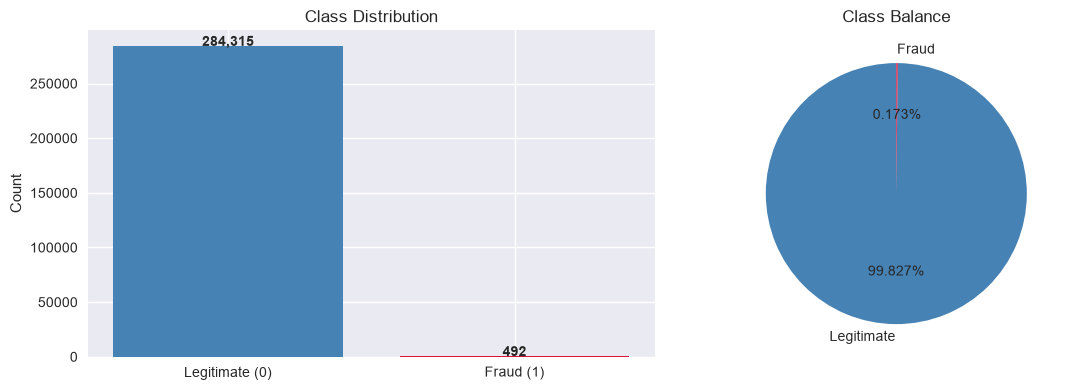


Imbalance Ratio: 578:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], 
            colors=['steelblue', 'crimson'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()
print(f"\nImbalance Ratio: {class_counts[0]/class_counts[1]:.0f}:1")

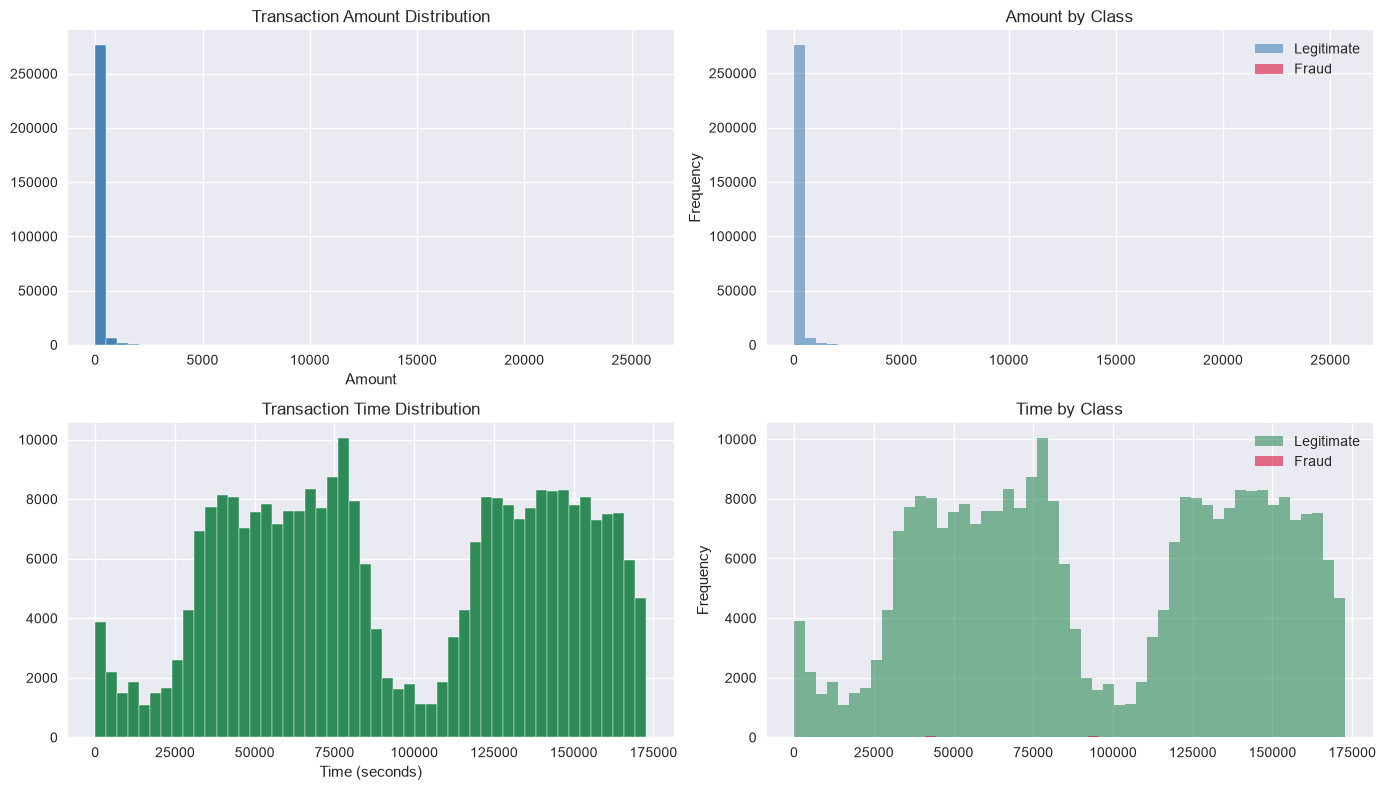

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount distribution
axes[0,0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Transaction Amount Distribution')
axes[0,0].set_xlabel('Amount')

# Amount by class
df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, alpha=0.6, 
                                   color='steelblue', ax=axes[0,1], label='Legitimate')
df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, alpha=0.6, 
                                   color='crimson', ax=axes[0,1], label='Fraud')
axes[0,1].set_title('Amount by Class')
axes[0,1].legend()

# Time distribution
axes[1,0].hist(df['Time'], bins=50, color='seagreen', edgecolor='white')
axes[1,0].set_title('Transaction Time Distribution')
axes[1,0].set_xlabel('Time (seconds)')

# Time by class
df[df['Class']==0]['Time'].plot(kind='hist', bins=50, alpha=0.6, 
                                 color='seagreen', ax=axes[1,1], label='Legitimate')
df[df['Class']==1]['Time'].plot(kind='hist', bins=50, alpha=0.6, 
                                 color='crimson', ax=axes[1,1], label='Fraud')
axes[1,1].set_title('Time by Class')
axes[1,1].legend()

plt.tight_layout()
plt.show()

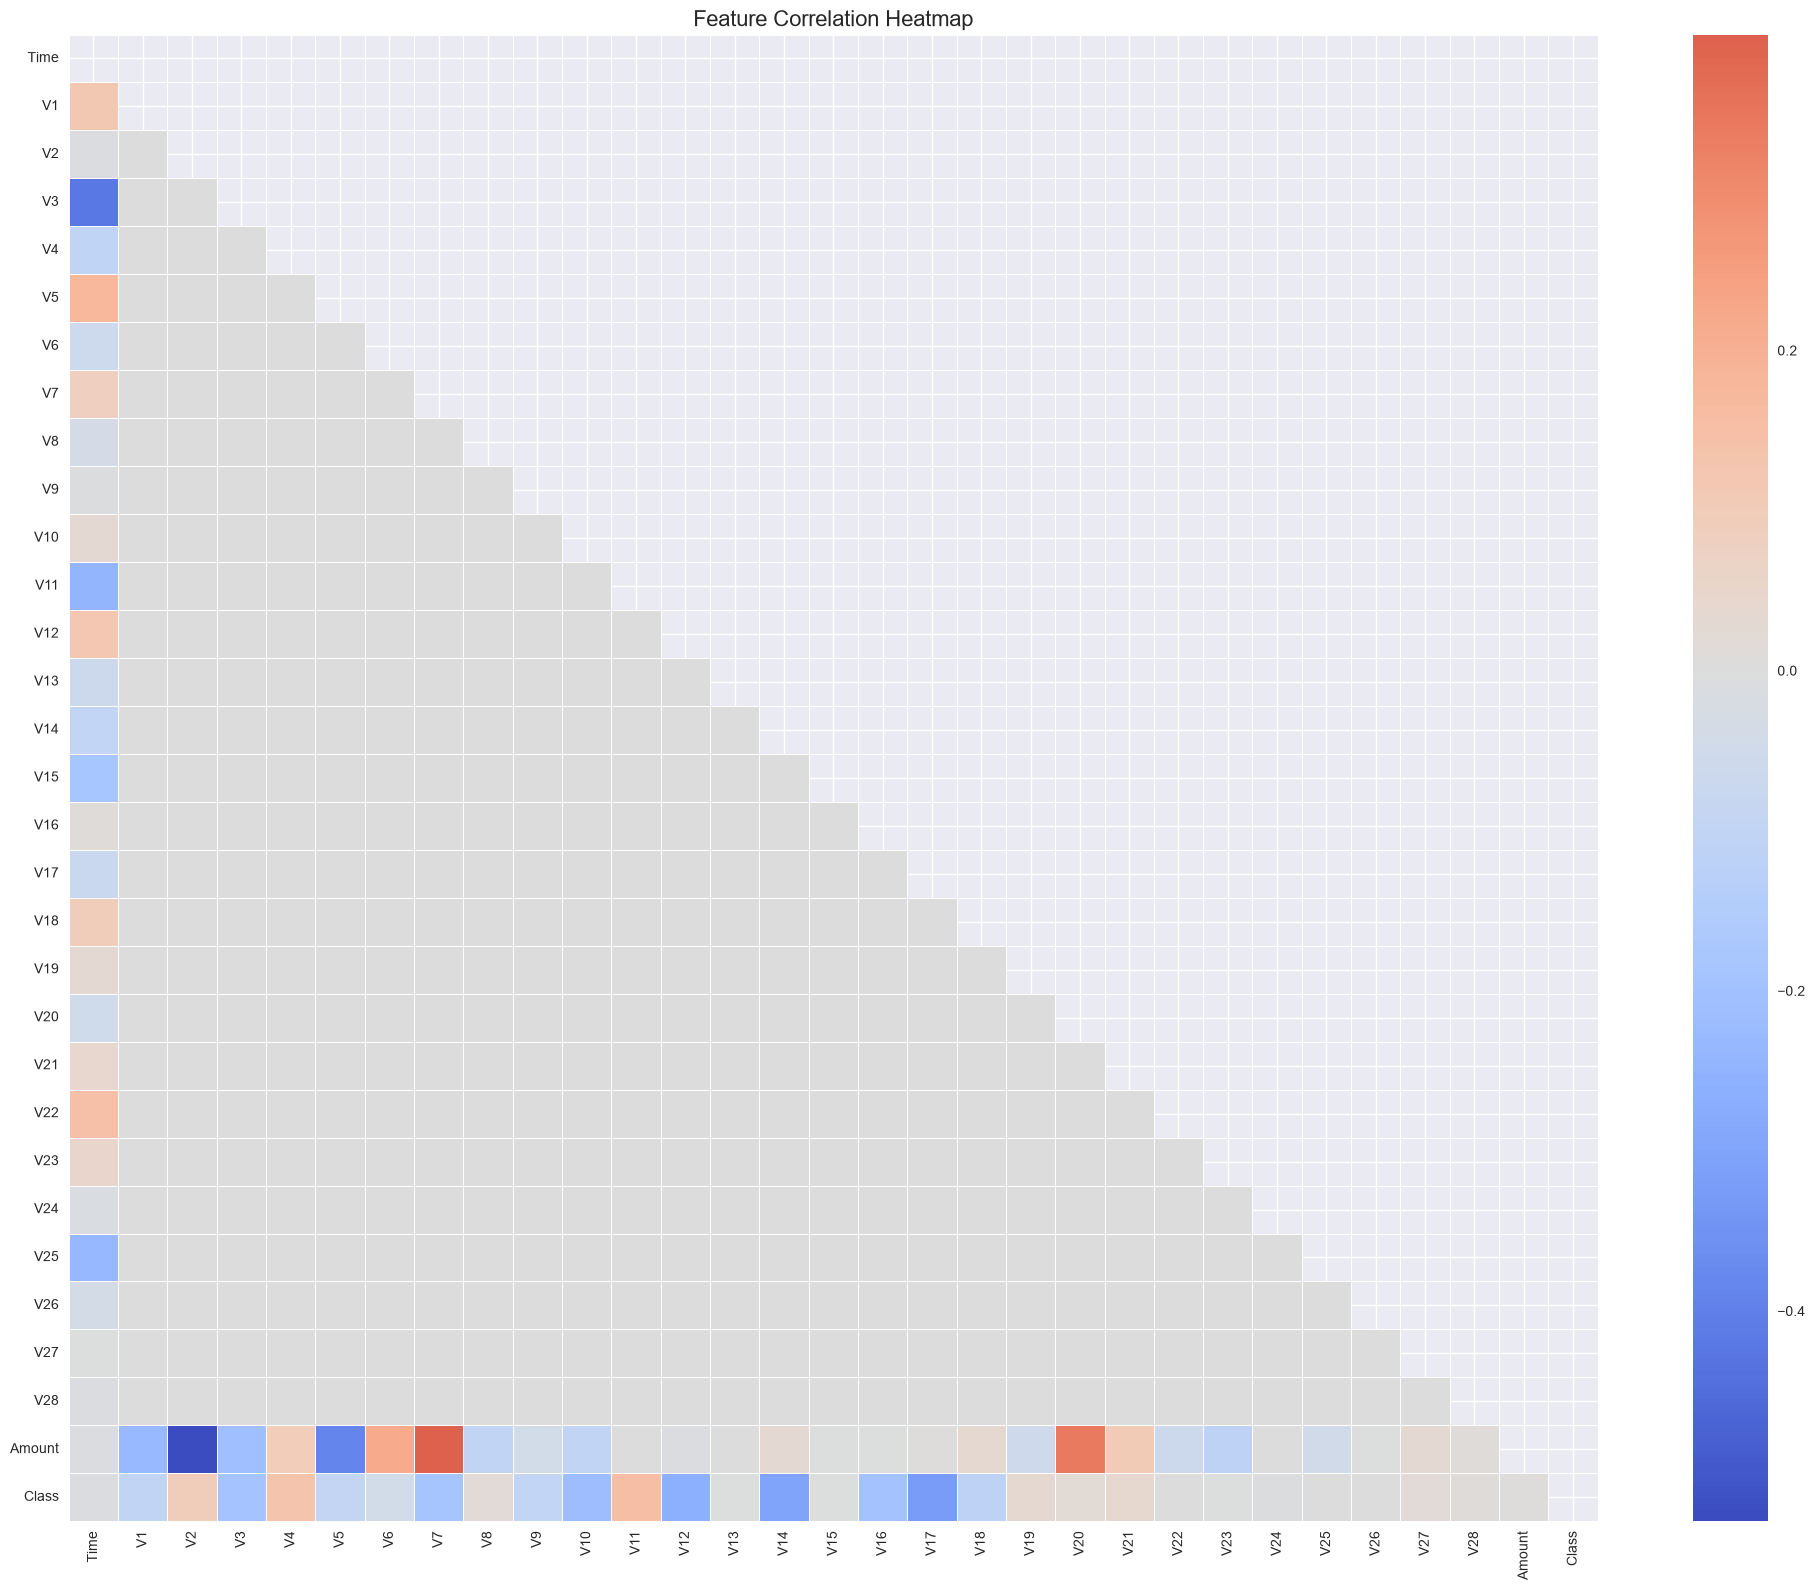

In [10]:
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

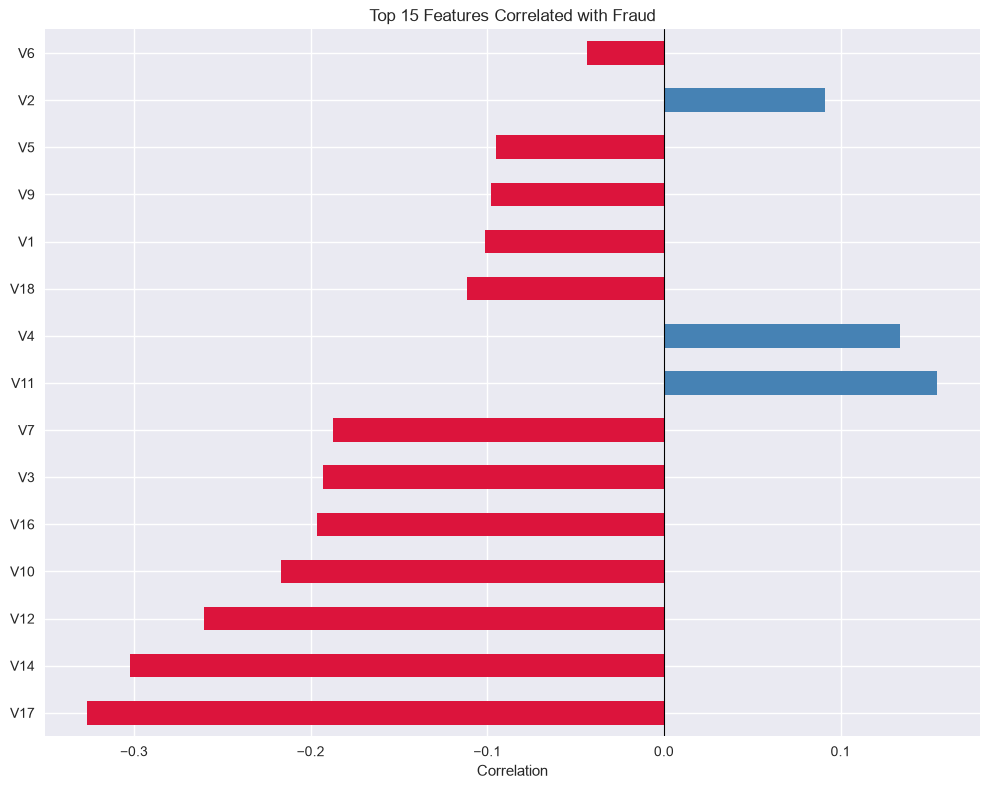


Top 10 correlated features:
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [11]:
fraud_corr = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
fraud_corr.head(15).plot(kind='barh', color=['crimson' if x < 0 else 'steelblue' 
                                               for x in fraud_corr.head(15)])
plt.title('Top 15 Features Correlated with Fraud')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 correlated features:\n", fraud_corr.head(10))

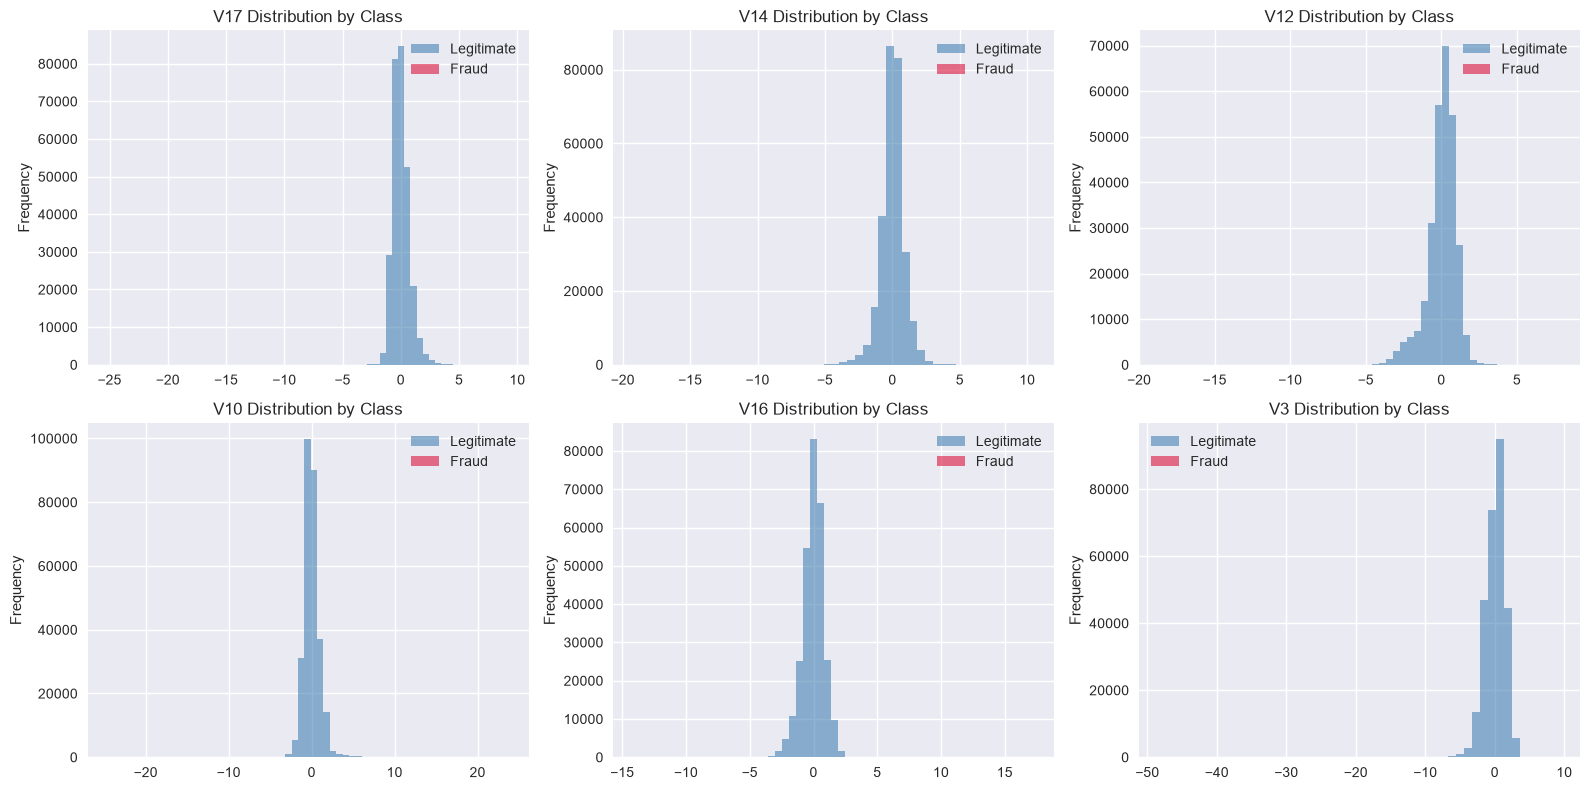

In [12]:
top_features = fraud_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    df[df['Class']==0][feature].plot(kind='hist', bins=50, alpha=0.6,
                                      color='steelblue', ax=axes[i], label='Legitimate')
    df[df['Class']==1][feature].plot(kind='hist', bins=50, alpha=0.6,
                                      color='crimson', ax=axes[i], label='Fraud')
    axes[i].set_title(f'{feature} Distribution by Class')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Scaled columns added, original dropped!")
print(df.shape)
df.head()

Scaled columns added, original dropped!
(284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scaled_Amount,scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


In [14]:
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:\n", y.value_counts())

X shape: (284807, 30)
y shape: (284807,)

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # keeps class ratio in both splits
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

X_train: (227845, 30)
X_test: (56962, 30)

Train class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
 Class
0    56864
1       98
Name: count, dtype: int64


In [16]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, y_train.value_counts().to_dict())
print("After SMOTE:", X_train_res.shape, y_train_res.value_counts().to_dict())

Before SMOTE: (227845, 30) {0: 227451, 1: 394}
After SMOTE: (454902, 30) {0: 227451, 1: 227451}


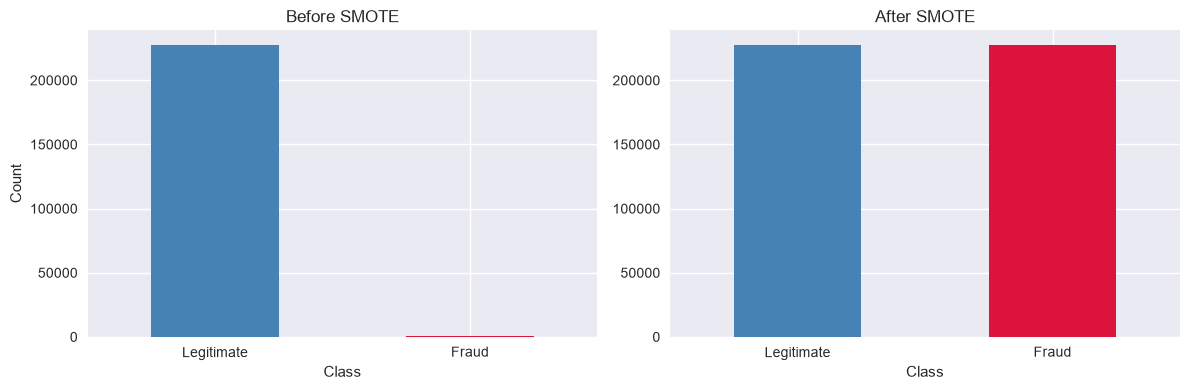

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# After
y_train_res.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9712187438987976


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9626204449140378


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

=== Gradient Boosting ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.11      0.91      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9806835930770733


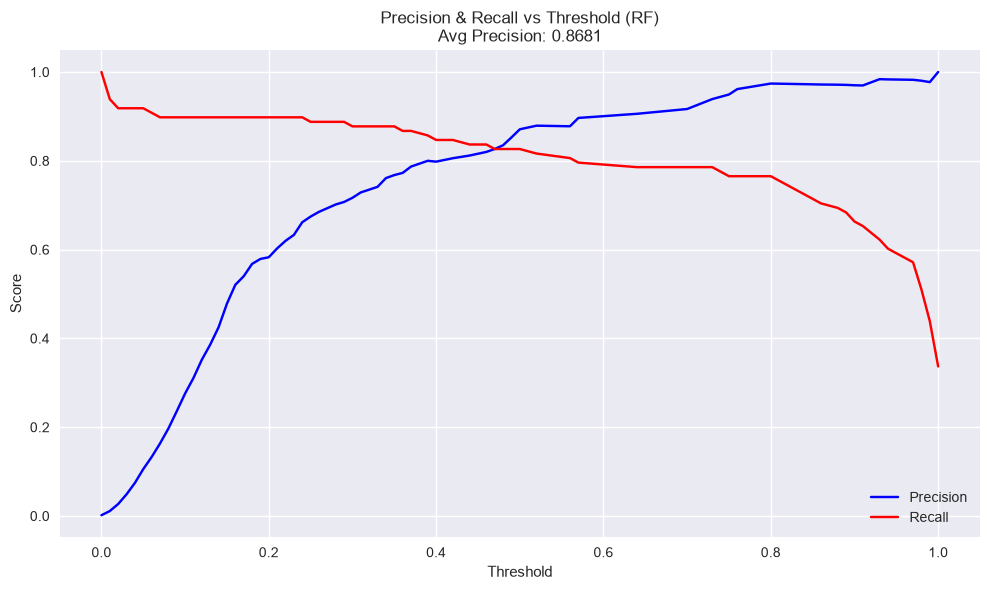

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
avg_precision = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds, recalls[:-1], 'r-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Precision & Recall vs Threshold (RF)\nAvg Precision: {avg_precision:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

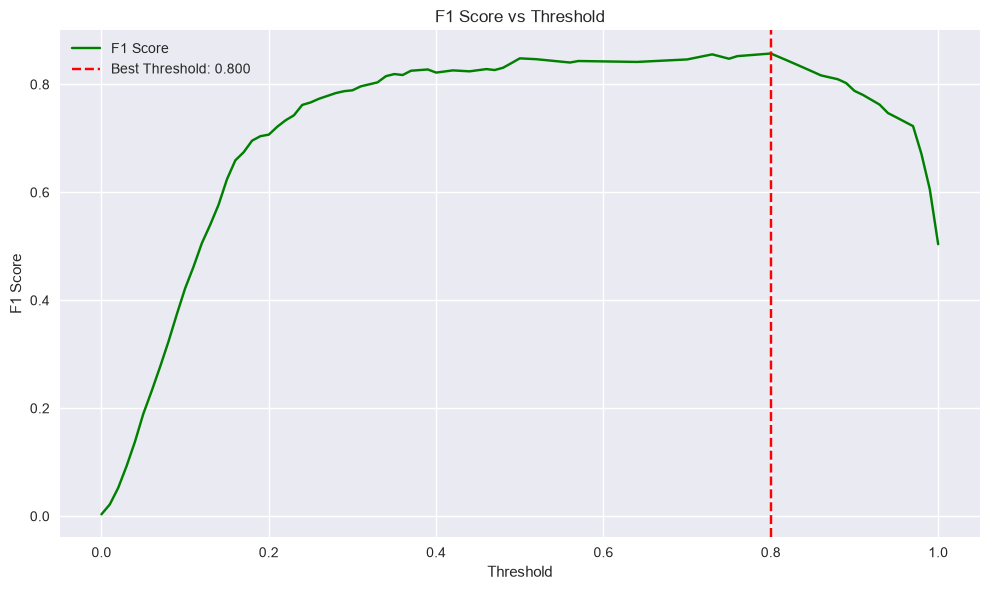

Best Threshold: 0.8000
Best F1 Score:  0.8571


In [22]:
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'g-', label='F1 Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', 
            label=f'Best Threshold: {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score:  {best_f1:.4f}")


In [23]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, best_threshold]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'FP':<8} {'FN':<8}")
print("-" * 65)

for thresh in thresholds_to_test:
    y_pred_custom = (y_prob_rf >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    
    print(f"{thresh:<12.3f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {fp:<8} {fn:<8}")

Threshold    Precision    Recall       F1           FP       FN      
-----------------------------------------------------------------
0.100        0.2759       0.8980       0.4221       231      10      
0.200        0.5828       0.8980       0.7068       63       10      
0.300        0.7167       0.8776       0.7890       34       12      
0.400        0.7981       0.8469       0.8218       21       15      
0.500        0.8710       0.8265       0.8482       12       17      
0.800        0.9740       0.7653       0.8571       2        23      


=== Random Forest with Tuned Threshold (0.8000) ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9626204449140378


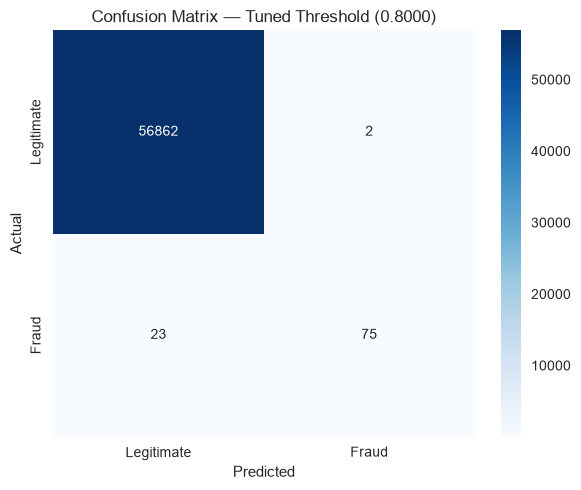

In [24]:
y_pred_tuned = (y_prob_rf >= best_threshold).astype(int)

print(f"=== Random Forest with Tuned Threshold ({best_threshold:.4f}) ===\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix — Tuned Threshold ({best_threshold:.4f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [25]:
default_pred = rf.predict(X_test)  # default threshold 0.5

metrics = {
    'Threshold': [0.5, best_threshold],
    'Precision': [
        classification_report(y_test, default_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['precision']
    ],
    'Recall': [
        classification_report(y_test, default_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['recall']
    ],
    'F1': [
        classification_report(y_test, default_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['f1-score']
    ]
}

comp_df = pd.DataFrame(metrics)
comp_df['Threshold'] = comp_df['Threshold'].apply(lambda x: f'{x:.4f}')
print("\n=== Before vs After Threshold Tuning ===")
print(comp_df.to_string(index=False))


=== Before vs After Threshold Tuning ===
Threshold  Precision   Recall       F1
   0.5000   0.879121 0.816327 0.846561
   0.8000   0.974026 0.765306 0.857143


In [26]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("       FRAUD DETECTION MODEL - FINAL SUMMARY REPORT")
print("=" * 60)

print("\n📊 DATASET OVERVIEW")
print("-" * 40)
print(f"  Total Transactions  : {len(df):,}")
print(f"  Legitimate          : {(y == 0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"  Fraudulent          : {(y == 1).sum():,} ({(y==1).mean()*100:.2f}%)")
print(f"  Features            : {X.shape[1]}")
print(f"  Imbalance Ratio     : {(y==0).sum() // (y==1).sum()}:1")

print("\n⚙️  PREPROCESSING")
print("-" * 40)
print("  ✔ Amount & Time scaled with RobustScaler")
print("  ✔ Train/Test Split   : 80% / 20% (stratified)")
print(f"  ✔ Training samples  : {X_train.shape[0]:,}")
print(f"  ✔ Test samples      : {X_test.shape[0]:,}")
print(f"  ✔ SMOTE applied     : {X_train_res.shape[0]:,} balanced training samples")

print("\n🤖 MODEL COMPARISON")
print("-" * 40)
results = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest'      : (y_pred_rf, y_prob_rf),
    'Gradient Boosting'  : (y_pred_gb, y_prob_gb),
}

print(f"  {'Model':<25} {'ROC-AUC':<10} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print(f"  {'-'*25} {'-'*10} {'-'*12} {'-'*10} {'-'*8}")
for name, (y_pred, y_prob) in results.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)
    p   = report['1']['precision']
    r   = report['1']['recall']
    f1  = report['1']['f1-score']
    print(f"  {name:<25} {auc:<10.4f} {p:<12.4f} {r:<10.4f} {f1:<8.4f}")

print("\n🏆 BEST MODEL: Random Forest")
print("-" * 40)
print(f"  Default Threshold (0.5)")
report_default = classification_report(y_test, y_pred_rf, output_dict=True)
print(f"    Precision : {report_default['1']['precision']:.4f}")
print(f"    Recall    : {report_default['1']['recall']:.4f}")
print(f"    F1 Score  : {report_default['1']['f1-score']:.4f}")

print(f"\n  Tuned Threshold ({best_threshold:.2f})")
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)
print(f"    Precision : {report_tuned['1']['precision']:.4f}  ✅ +{report_tuned['1']['precision']-report_default['1']['precision']:.4f}")
print(f"    Recall    : {report_tuned['1']['recall']:.4f}")
print(f"    F1 Score  : {report_tuned['1']['f1-score']:.4f}  ✅ +{report_tuned['1']['f1-score']-report_default['1']['f1-score']:.4f}")

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()
print(f"\n📋 CONFUSION MATRIX (Tuned Threshold)")
print("-" * 40)
print(f"  True Positives  (Fraud caught)       : {tp}")
print(f"  False Negatives (Fraud missed)       : {fn}")
print(f"  False Positives (Legitimate blocked) : {fp}")
print(f"  True Negatives  (Legitimate passed)  : {tn:,}")

print("\n💡 BUSINESS IMPACT")
print("-" * 40)
print(f"  Fraud cases in test set  : 98")
print(f"  Fraud cases caught       : {tp} ({tp/98*100:.1f}%)")
print(f"  Fraud cases missed       : {fn} ({fn/98*100:.1f}%)")
print(f"  Legitimate txns blocked  : {fp} (out of {tn+fp:,})")
print(f"  Block rate on legit txns : {fp/(tn+fp)*100:.4f}%")

print("\n✅ CONCLUSION")
print("-" * 40)
print("  Random Forest with threshold=0.8 is the final model.")
print("  It achieves 97% precision with minimal false alarms,")
print("  catching 77% of all fraudulent transactions.")
print("=" * 60)

       FRAUD DETECTION MODEL - FINAL SUMMARY REPORT

📊 DATASET OVERVIEW
----------------------------------------
  Total Transactions  : 284,807
  Legitimate          : 284,315 (99.83%)
  Fraudulent          : 492 (0.17%)
  Features            : 30
  Imbalance Ratio     : 577:1

⚙️  PREPROCESSING
----------------------------------------
  ✔ Amount & Time scaled with RobustScaler
  ✔ Train/Test Split   : 80% / 20% (stratified)
  ✔ Training samples  : 227,845
  ✔ Test samples      : 56,962
  ✔ SMOTE applied     : 454,902 balanced training samples

🤖 MODEL COMPARISON
----------------------------------------
  Model                     ROC-AUC    Precision    Recall     F1      
  ------------------------- ---------- ------------ ---------- --------
  Logistic Regression       0.9712     0.0591       0.9184     0.1110  
  Random Forest             0.9626     0.8791       0.8163     0.8466  
  Gradient Boosting         0.9807     0.1085       0.9082     0.1939  

🏆 BEST MODEL: Random Forest

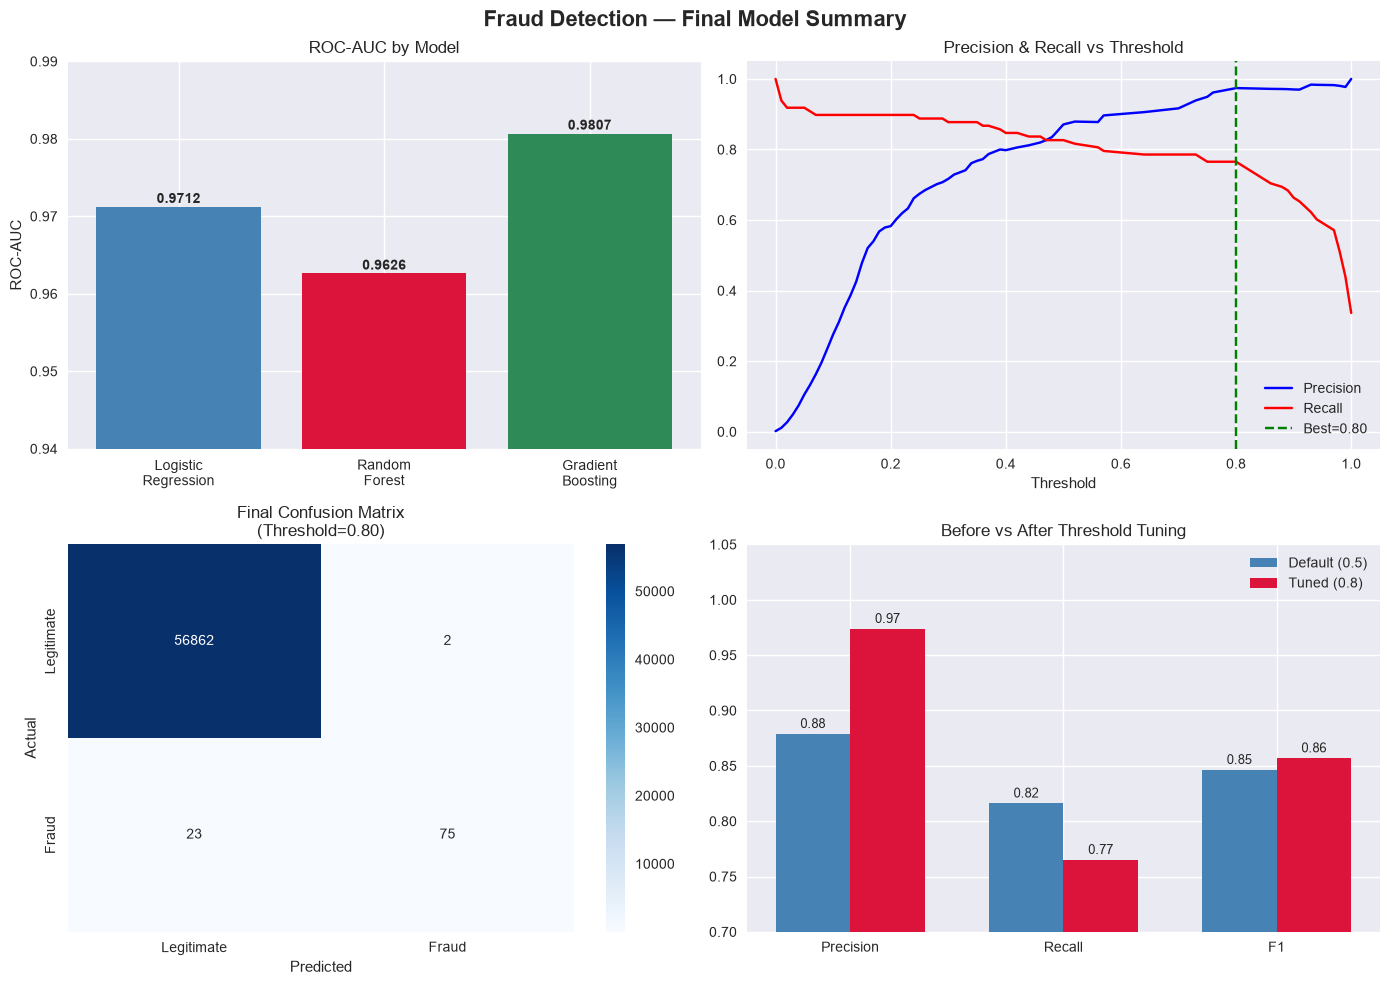

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Detection — Final Model Summary', fontsize=16, fontweight='bold')

# 1. Model comparison bar chart
model_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
aucs = [roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)]
colors = ['steelblue', 'crimson', 'seagreen']
bars = axes[0,0].bar(model_names, aucs, color=colors)
axes[0,0].set_title('ROC-AUC by Model')
axes[0,0].set_ylim(0.94, 0.99)
axes[0,0].set_ylabel('ROC-AUC')
for bar, auc in zip(bars, aucs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                   f'{auc:.4f}', ha='center', fontweight='bold')

# 2. Precision-Recall tradeoff
axes[0,1].plot(thresholds, precisions[:-1], 'b-', label='Precision')
axes[0,1].plot(thresholds, recalls[:-1], 'r-', label='Recall')
axes[0,1].axvline(x=best_threshold, color='green', linestyle='--',
                   label=f'Best={best_threshold:.2f}')
axes[0,1].set_title('Precision & Recall vs Threshold')
axes[0,1].set_xlabel('Threshold')
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Final confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1,0].set_title(f'Final Confusion Matrix\n(Threshold={best_threshold:.2f})')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

# 4. Before vs After tuning
metrics_names = ['Precision', 'Recall', 'F1']
before = [report_default['1']['precision'],
          report_default['1']['recall'],
          report_default['1']['f1-score']]
after  = [report_tuned['1']['precision'],
          report_tuned['1']['recall'],
          report_tuned['1']['f1-score']]

x = np.arange(len(metrics_names))
width = 0.35
axes[1,1].bar(x - width/2, before, width, label='Default (0.5)', color='steelblue')
axes[1,1].bar(x + width/2, after,  width, label=f'Tuned ({best_threshold:.1f})',  color='crimson')
axes[1,1].set_title('Before vs After Threshold Tuning')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metrics_names)
axes[1,1].set_ylim(0.7, 1.05)
axes[1,1].legend()
for i, (b, a) in enumerate(zip(before, after)):
    axes[1,1].text(i - width/2, b + 0.005, f'{b:.2f}', ha='center', fontsize=9)
    axes[1,1].text(i + width/2, a + 0.005, f'{a:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
import joblib

joblib.dump(rf, 'fraud_detection_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved as: fraud_detection_rf_model.pkl")
print("✅ Scaler saved as: scaler.pkl")
print(f"✅ Use threshold: {best_threshold:.2f} for predictions")

# Quick test load
model_loaded = joblib.load('fraud_detection_rf_model.pkl')
print("\n✅ Model reload test passed!")

✅ Model saved as: fraud_detection_rf_model.pkl
✅ Scaler saved as: scaler.pkl
✅ Use threshold: 0.80 for predictions

✅ Model reload test passed!
